In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samaneheslamifar/facial-emotion-expressions")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/samaneheslamifar/facial-emotion-expressions/versions/1


In [ ]:
import os

# List the contents of the downloaded directory
print("Contents of the dataset directory:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Streaming output truncated to the last 5000 lines.
                23301.jpg
                2267.jpg
                24.jpg
                29695.jpg
                19077.jpg
                25382.jpg
                5305.jpg
                1363.jpg
                13649.jpg
                18580.jpg
                34950.jpg
                10791.jpg
                22722.jpg
                31621.jpg
                25837.jpg
                3046.jpg
                3267.jpg
                15852.jpg
                2921.jpg
                27166.jpg
                11351.jpg
                30903.jpg
                11620.jpg
                7062.jpg
                572.jpg
                21228.jpg
                28340.jpg
                10678.jpg
                22133.jpg
                223.jpg
                16334.jpg
                34549.jpg
                23688.jpg
                20376.jpg
                218.jpg
                22142.jpg
                22903.jpg
   

In [ ]:
import tensorflow as tf

# Define image dimensions and batch size
img_height, img_width = 48, 48
batch_size = 32

# Construct the paths for training and validation data
train_data_dir = os.path.join(path, 'images', 'train')
validation_data_dir = os.path.join(path, 'images', 'validation')

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

# Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_data_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

print("\nDatasets loaded successfully!")
print(f"Training dataset class names: {train_ds.class_names}")
print(f"Validation dataset class names: {val_ds.class_names}")

Found 28821 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.

Datasets loaded successfully!
Training dataset class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Validation dataset class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
# Normalize pixel values to be between 0 and 1
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_processed = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds_processed = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("Datasets normalized successfully!")

Datasets normalized successfully!


In [ ]:
# Configure the datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds_optimized = train_ds_processed.cache().prefetch(buffer_size=AUTOTUNE)
val_ds_optimized = val_ds_processed.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets configured for performance!")

Datasets configured for performance!


In [ ]:
num_classes = len(train_ds.class_names)

model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

print("CNN model built successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,591 (2.36 MB)

 Trainable params: 619,591 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

CNN model built successfully!


The CNN model architecture is now defined. The next steps will involve compiling the model (defining the optimizer, loss function, and metrics) and then training it using our preprocessed datasets.

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])

print("Model compiled successfully!")

Model compiled successfully!


With the model compiled, we are now ready to train it using our optimized training and validation datasets. I will set the number of epochs to 10 for demonstration purposes, but this can be adjusted based on performance.

In [ ]:
epochs = 10
history = model.fit(
    train_ds_optimized,
    validation_data=val_ds_optimized,
    epochs=epochs
)

print("Model training complete!")

Epoch 1/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 124s 135ms/step - accuracy: 0.3247 - loss: 1.6850 - val_accuracy: 0.4355 - val_loss: 1.4726
Epoch 2/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 117s 129ms/step - accuracy: 0.4538 - loss: 1.4143 - val_accuracy: 0.5055 - val_loss: 1.3140
Epoch 3/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accuracy: 0.5092 - loss: 1.2890 - val_accuracy: 0.5262 - val_loss: 1.2365
Epoch 4/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 111s 123ms/step - accuracy: 0.5394 - loss: 1.2105 - val_accuracy: 0.5459 - val_loss: 1.2073
Epoch 5/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 112s 125ms/step - accuracy: 0.5637 - loss: 1.1464 - val_accuracy: 0.5451 - val_loss: 1.2015
Epoch 6/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 111s 123ms/step - accuracy: 0.5869 - loss: 1.0869 - val_accuracy: 0.5529 - val_loss: 1.2044
Epoch 7/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 113s 126ms/step - accuracy: 0.6105 - loss: 1.0316 - val_accuracy: 0.5541 - val_loss: 1.2130
Epoch 8/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 111s 124ms/step - accuracy: 0.6299 -

The model has been trained! Now, we can evaluate its performance, visualize the training history, and finally, set up a function to predict emotions from new, unseen images.

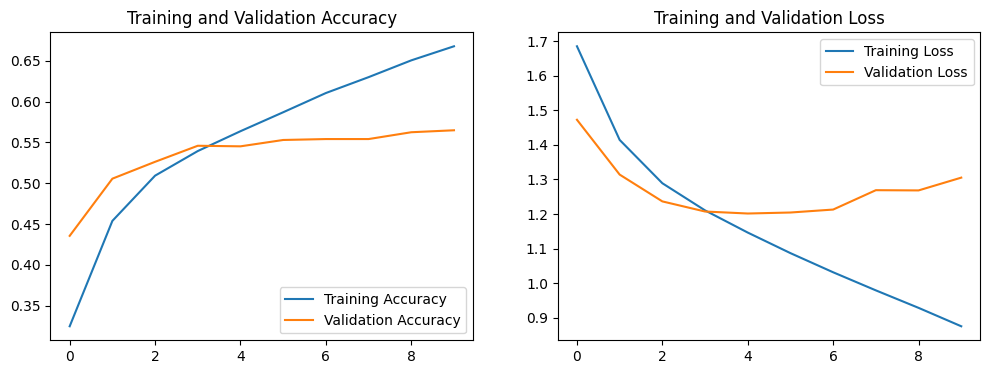

Training history visualized!


In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

print("Training history visualized!")

The training history plots provide insights into the model's learning process. Now, let's prepare a function to predict facial emotions from new, unseen images. This function will handle loading, resizing, and normalizing the image before passing it to the trained model for prediction.

The `predict_emotion` function is now ready to use. To test it, you can upload an image file and then call this function with the path to your uploaded image. For example, if you upload an image named `test_image.jpg`, you would use `predict_emotion('test_image.jpg')`.

In [ ]:
# Evaluate the model
print("\nEvaluating the model on the validation set:")
loss, accuracy = model.evaluate(val_ds_optimized)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


Evaluating the model on the validation set:
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5648 - loss: 1.3053
Validation Loss: 1.3053
Validation Accuracy: 0.5648


This evaluation provides the final performance metrics of the model on unseen data. Next, you can generate a confusion matrix and classification report for a more detailed breakdown of performance across different emotion classes, or proceed to use the `predict_emotion` function for individual images.

### Making Predictions on New Images

Now that the model has been trained and evaluated, let's use it to predict emotions from new, unseen images. First, I'll explicitly define `class_names` from the training dataset.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Get class names from the training dataset
class_names = train_ds.class_names
print(f"Emotion classes: {class_names}")

# Define the predict_emotion function
def predict_emotion(image_path):
    # Load the image and resize it to the target dimensions
    img = image.load_img(image_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch

    # Normalize the image (as done during training)
    img_array = img_array / 255.0

    # Make prediction
    predictions = model.predict(img_array)

    # Get the predicted class and confidence
    predicted_class_index = np.argmax(predictions[0])
    predicted_emotion = class_names[predicted_class_index]
    confidence = np.max(predictions[0])

    print(f"Predicted Emotion: {predicted_emotion}")
    print(f"Confidence: {confidence:.2f}")

    return predicted_emotion, confidence

print("predict_emotion function defined!")

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
predict_emotion function defined!


To test the `predict_emotion` function, you can upload an image file using the cell below. Once uploaded, replace `'your_image.jpg'` in the prediction cell with the name of your uploaded file.

In [ ]:
from google.colab import files

# Upload an image file
uploaded = files.upload()

# Get the name of the uploaded file
if uploaded:
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
        uploaded_image_path = fn
        break # Assuming only one file is uploaded
else:
    uploaded_image_path = None



Saving neutral1.jpg to neutral1 (1).jpg
User uploaded file "neutral1 (1).jpg"


Now, let's make a prediction using the uploaded image. Replace `uploaded_image_path` with the actual filename if you uploaded multiple or wish to use a specific one.

In [ ]:
if uploaded_image_path:
    predicted_emotion, confidence = predict_emotion(uploaded_image_path)
else:
    print("No image was uploaded. Please upload an image first.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predicted Emotion: happy
Confidence: 0.98


### Modifying the Dataset: Removing 'disgust' and 'neutral' classes

To remove 'disgust' and 'neutral' from the classifications, I will filter the `train_ds` and `val_ds` datasets. This means creating new datasets that only contain the remaining 5 emotion classes. Then, I'll re-initialize the model with the updated number of classes and retrain it.

In [ ]:
import tensorflow as tf

# Original class names were: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Identify classes to exclude and their indices
excluded_class_names = ['disgust', 'neutral']
original_class_names = train_ds.class_names # Assuming train_ds from previous cells is available

excluded_class_indices = []
for name in excluded_class_names:
    if name in original_class_names:
        excluded_class_indices.append(original_class_names.index(name))

print(f"Original class names: {original_class_names}")
print(f"Classes to exclude: {excluded_class_names}")
print(f"Indices of excluded classes: {excluded_class_indices}")

# Create the new mapping for remaining classes
updated_class_names = [name for name in original_class_names if name not in excluded_class_names]
num_classes = len(updated_class_names)

original_to_new_label_map = {}
new_idx = 0
for original_idx, class_name in enumerate(original_class_names):
    if class_name not in excluded_class_names:
        original_to_new_label_map[original_idx] = new_idx
        new_idx += 1

print(f"\nUpdated class names: {updated_class_names}")
print(f"Updated number of classes: {num_classes}")
print(f"Original to new label map: {original_to_new_label_map}")

# Convert the dictionary to a TensorFlow lookup table for mapping
keys_tensor = tf.constant(list(original_to_new_label_map.keys()), dtype=tf.int64)
values_tensor = tf.constant(list(original_to_new_label_map.values()), dtype=tf.int64)
table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys_tensor, values_tensor),
    default_value=-1 # A default value for labels not in keys (should not happen after filtering)
)

# Filter and remap function for individual elements
def filter_and_remap_single_element(image, label):
    # Ensure label is tf.int64 for lookup table compatibility
    label_int64 = tf.cast(label, tf.int64)
    # Check if the label is NOT one of the excluded indices
    is_kept = tf.reduce_all([tf.not_equal(label_int64, idx) for idx in excluded_class_indices])
    new_label = tf.cond(is_kept, lambda: table.lookup(label_int64), lambda: tf.constant(-1, dtype=tf.int64))
    return image, new_label, is_kept

# Function to apply filter and remapping to a dataset
def process_dataset(dataset, batch_size):
    # Unbatch, filter individual elements, remap labels, then rebatch
    dataset = dataset.unbatch()
    dataset = dataset.map(filter_and_remap_single_element, num_parallel_calls=AUTOTUNE)
    dataset = dataset.filter(lambda image, new_label, is_kept: is_kept) # Keep only filtered elements
    dataset = dataset.map(lambda image, new_label, is_kept: (image, new_label), num_parallel_calls=AUTOTUNE) # Drop is_kept flag
    return dataset

# Apply processing to training and validation datasets
# Note: train_ds and val_ds are already batched, we need to unbatch them first.
train_ds_filtered_remapped = process_dataset(train_ds, batch_size)
val_ds_filtered_remapped = process_dataset(val_ds, batch_size)

# Re-normalize and optimize the filtered datasets
# Normalize pixel values to be between 0 and 1
normalization_layer = tf.keras.layers.Rescaling(1./255)

# First normalize, then batch
train_ds_processed_filtered = train_ds_filtered_remapped.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds_processed_filtered = val_ds_filtered_remapped.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

# Now batch, then cache and prefetch
AUTOTUNE = tf.data.AUTOTUNE # Assuming AUTOTUNE is defined in an earlier cell
train_ds_optimized_filtered = train_ds_processed_filtered.batch(batch_size).cache().prefetch(buffer_size=AUTOTUNE)
val_ds_optimized_filtered = val_ds_processed_filtered.batch(batch_size).cache().prefetch(buffer_size=AUTOTUNE)

print("Filtered, remapped, and optimized datasets created.")

# Verify approximate sizes (number of batches) for debugging
try:
    train_approx_elements = sum(1 for _ in train_ds_filtered_remapped)
    val_approx_elements = sum(1 for _ in val_ds_filtered_remapped)
    print(f"Number of elements in filtered training dataset: {train_approx_elements}")
    print(f"Number of elements in filtered validation dataset: {val_approx_elements}")

    print(f"Number of batches in optimized filtered training dataset: {tf.data.experimental.cardinality(train_ds_optimized_filtered).numpy()}")
    print(f"Number of batches in optimized filtered validation dataset: {tf.data.experimental.cardinality(val_ds_optimized_filtered).numpy()}")
except Exception as e:
    print(f"Could not calculate exact dataset sizes: {e}")

Original class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Classes to exclude: ['disgust', 'neutral']
Indices of excluded classes: [1, 4]

Updated class names: ['angry', 'fear', 'happy', 'sad', 'surprise']
Updated number of classes: 5
Original to new label map: {0: 0, 2: 1, 3: 2, 5: 3, 6: 4}
Filtered, remapped, and optimized datasets created.
Number of elements in filtered training dataset: 23403
Number of elements in filtered validation dataset: 5739
Number of batches in optimized filtered training dataset: -2
Number of batches in optimized filtered validation dataset: -2


### Rebuilding and Retraining the Model with 5 Classes

Now that the dataset has been filtered to 5 classes, we need to rebuild the CNN model with the updated `num_classes` in the final `Dense` layer. After rebuilding, we'll recompile and retrain the model.

In [ ]:
# Rebuild the model with the updated number of classes
model_5_classes = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(num_classes, activation='softmax') # num_classes is now 5
])

model_5_classes.summary()

print("CNN model rebuilt successfully for 5 classes!")

# Recompile the model
model_5_classes.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Model recompiled successfully!")

# Retrain the model
epochs = 15 # Increased epochs slightly for initial retraining
history_5_classes = model_5_classes.fit(
    train_ds_optimized_filtered,
    validation_data=val_ds_optimized_filtered,
    epochs=epochs
)

print("Model retraining complete with 5 classes!")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,591 (2.36 MB)

 Trainable params: 619,591 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

CNN model rebuilt successfully for 5 classes!
Model recompiled successfully!
Epoch 1/15
    732/Unknown 98s 131ms/step - accuracy: 0.3161 - loss: 1.5685

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


732/732 ━━━━━━━━━━━━━━━━━━━━ 105s 141ms/step - accuracy: 0.3821 - loss: 1.4513 - val_accuracy: 0.4910 - val_loss: 1.2389
Epoch 2/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 93s 127ms/step - accuracy: 0.5148 - loss: 1.1849 - val_accuracy: 0.5341 - val_loss: 1.1419
Epoch 3/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 93s 127ms/step - accuracy: 0.5665 - loss: 1.0753 - val_accuracy: 0.5769 - val_loss: 1.0703
Epoch 4/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 93s 127ms/step - accuracy: 0.5990 - loss: 0.9991 - val_accuracy: 0.5867 - val_loss: 1.0466
Epoch 5/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.6246 - loss: 0.9430 - val_accuracy: 0.5924 - val_loss: 1.0174
Epoch 6/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.6511 - loss: 0.8918 - val_accuracy: 0.6045 - val_loss: 0.9986
Epoch 7/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.6621 - loss: 0.8444 - val_accuracy: 0.6118 - val_loss: 0.9902
Epoch 8/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 93s 127ms/step - accuracy: 0.6853 - loss: 0.7980 - va

### Evaluating the New Model and Discussing Accuracy Improvement

Now, let's evaluate the newly trained model (with 5 classes) and then discuss strategies to reach the target accuracy of 90%.


Evaluating the 5-class model on the filtered validation set:
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.6041 - loss: 1.3416
Validation Loss (5 classes): 1.3416
Validation Accuracy (5 classes): 0.6041


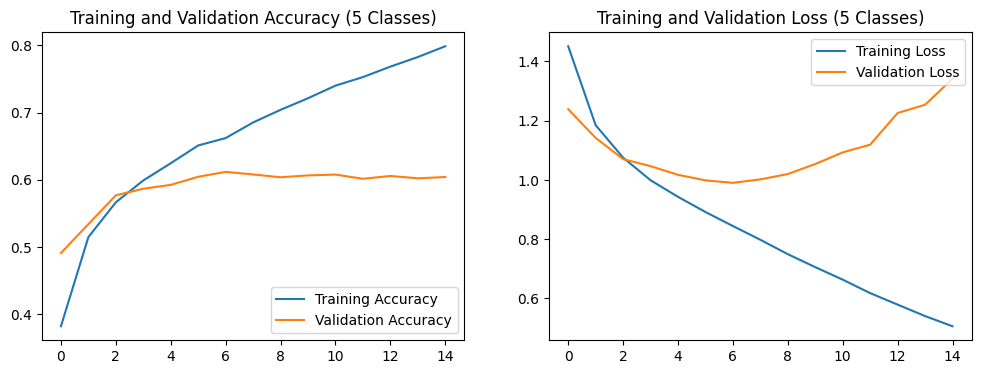

In [ ]:
# Evaluate the new model
print("\nEvaluating the 5-class model on the filtered validation set:")
loss_5_classes, accuracy_5_classes = model_5_classes.evaluate(val_ds_optimized_filtered)
print(f"Validation Loss (5 classes): {loss_5_classes:.4f}")
print(f"Validation Accuracy (5 classes): {accuracy_5_classes:.4f}")

# Plotting training history for the new model
acc_5 = history_5_classes.history['accuracy']
val_acc_5 = history_5_classes.history['val_accuracy']

loss_5 = history_5_classes.history['loss']
val_loss_5 = history_5_classes.history['val_loss']

epochs_range_5 = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_5, acc_5, label='Training Accuracy')
plt.plot(epochs_range_5, val_acc_5, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (5 Classes)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_5, loss_5, label='Training Loss')
plt.plot(epochs_range_5, val_loss_5, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (5 Classes)')
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Get class names from the training dataset
class_names = train_ds.class_names
print(f"Emotion classes: {class_names}")

# Define the predict_emotion function
def predict_emotion(image_path):
    # Load the image and resize it to the target dimensions
    img = image.load_img(image_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch

    # Normalize the image (as done during training)
    img_array = img_array / 255.0

    # Make prediction
    predictions = model.predict(img_array)

    # Get the predicted class and confidence
    predicted_class_index = np.argmax(predictions[0])
    predicted_emotion = class_names[predicted_class_index]
    confidence = np.max(predictions[0])

    print(f"Predicted Emotion: {predicted_emotion}")
    print(f"Confidence: {confidence:.2f}")

    return predicted_emotion, confidence

print("predict_emotion function defined!")

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
predict_emotion function defined!


In [ ]:
from google.colab import files

# Upload an image file
uploaded = files.upload()

# Get the name of the uploaded file
if uploaded:
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')
        uploaded_image_path = fn
        break # Assuming only one file is uploaded
else:
    uploaded_image_path = None



Saving angry2.jpg to angry2.jpg
User uploaded file "angry2.jpg"


In [ ]:
if uploaded_image_path:
    predicted_emotion, confidence = predict_emotion(uploaded_image_path)
else:
    print("No image was uploaded. Please upload an image first.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Emotion: neutral
Confidence: 0.55
